# Ejercicio: Predicción de NO2(GT) usando Redes Neuronales

Este cuaderno realiza un análisis del dataset de calidad del aire y entrena una red neuronal para predecir los niveles de **NO2(GT)**. Incluye visualizaciones avanzadas y un flujo de trabajo estructurado inspirado en el ejemplo de clase.

In [175]:
import os
import random
import numpy as np
import tensorflow as tf

# Semilla fija para reproducibilidad
seed_value = 42

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

print(f"Semillas fijadas en: {seed_value}")

print("Cargando librerías...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

print("Librerías cargadas correctamente.")

Semillas fijadas en: 42
Cargando librerías...
Librerías cargadas correctamente.


## 1. Obtención de los datos

Cargamos el dataset ajustando el separador `;` y el separador decimal `,`.

In [176]:
print("Leyendo CSV...")
# El dataset usa ';' como separador y ',' como decimal
df = pd.read_csv('AirQuality.csv', sep=';', decimal=',', skipfooter=114, engine='python')

# Eliminar columnas y filas vacías que a veces aparecen al final del CSV
df = df.dropna(axis=1, how='all')
df = df.dropna(axis=0, how='all')

print(f"Dimensiones iniciales del dataset: {df.shape}")
df.head()

Leyendo CSV...
Dimensiones iniciales del dataset: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


## 2. Limpieza de Datos

El dataset utiliza `-200` para representar valores nulos o faltantes. Los reemplazamos por `NaN` y gestionamos la limpieza.

In [177]:
print("Limpiando datos (gestionando -200 como nulos)...")
# Reemplazar -200 por NaN
df = df.replace(-200, np.nan)

# Eliminamos filas donde la variable objetivo es nula
df = df.dropna(subset=['NO2(GT)'])

# Completamos el resto de valores numéricos con la mediana
df = df.fillna(df.median(numeric_only=True))

print(f"Dimensiones tras limpieza: {df.shape}")

Limpiando datos (gestionando -200 como nulos)...
Dimensiones tras limpieza: (7715, 15)


## 3. Estudio de Correlaciones y Selección de Características

Analizamos la relación entre las variables para seleccionar las 3 mejores para predecir **NO2(GT)**.

Estudiando correlaciones...


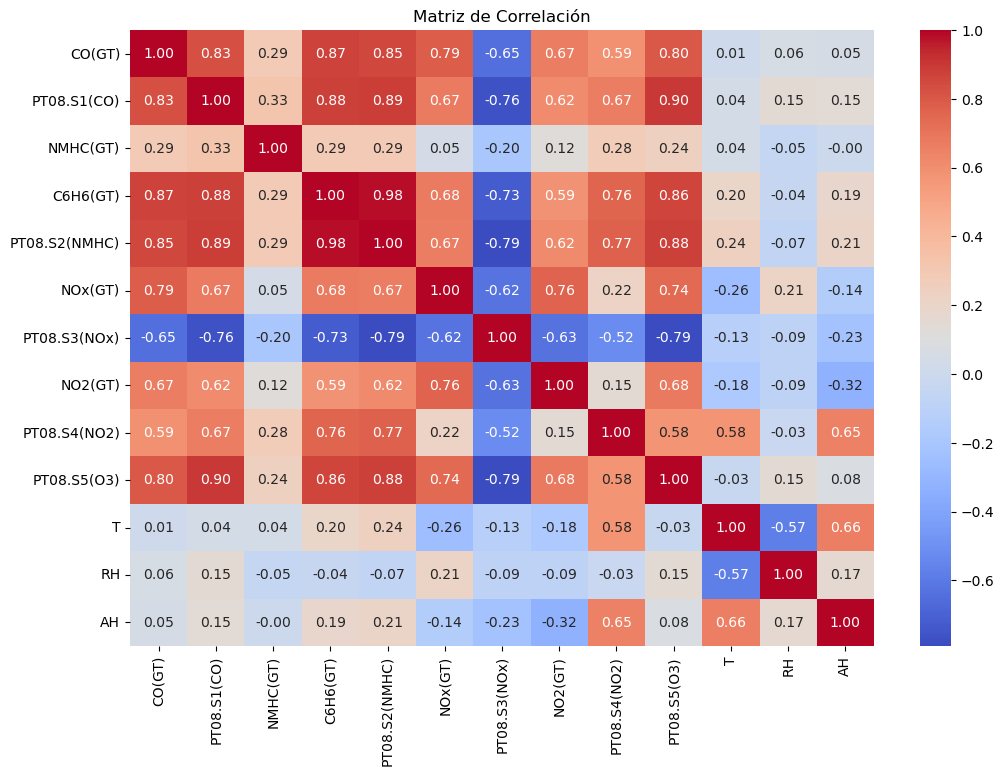

Correlación absoluta con NO2(GT):
NO2(GT)          1.000000
NOx(GT)          0.763111
PT08.S5(O3)      0.679732
CO(GT)           0.667430
PT08.S3(NOx)     0.630766
PT08.S2(NMHC)    0.620951
PT08.S1(CO)      0.615070
C6H6(GT)         0.587070
AH               0.324320
T                0.181606
PT08.S4(NO2)     0.152112
NMHC(GT)         0.123325
RH               0.088201
Name: NO2(GT), dtype: float64

Seleccionando las 3 mejores características...
Características elegidas: ['NOx(GT)', 'PT08.S5(O3)', 'CO(GT)', 'PT08.S3(NOx)', 'PT08.S2(NMHC)', 'PT08.S1(CO)', 'C6H6(GT)', 'AH', 'T', 'PT08.S4(NO2)', 'NMHC(GT)', 'RH']


In [178]:
print("Estudiando correlaciones...")
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# Correlaciones con la variable objetivo
target_corr = corr_matrix['NO2(GT)'].abs().sort_values(ascending=False)
print("Correlación absoluta con NO2(GT):")
print(target_corr)

print("\nSeleccionando las 3 mejores características...")
features = target_corr.index[1:13].tolist()
print(f"Características elegidas: {features}")

## 4. Visualización de Características

Antes de entrenar, visualizamos cómo se relacionan las características seleccionadas con el objetivo.

Generando representaciones gráficas de las variables seleccionadas...


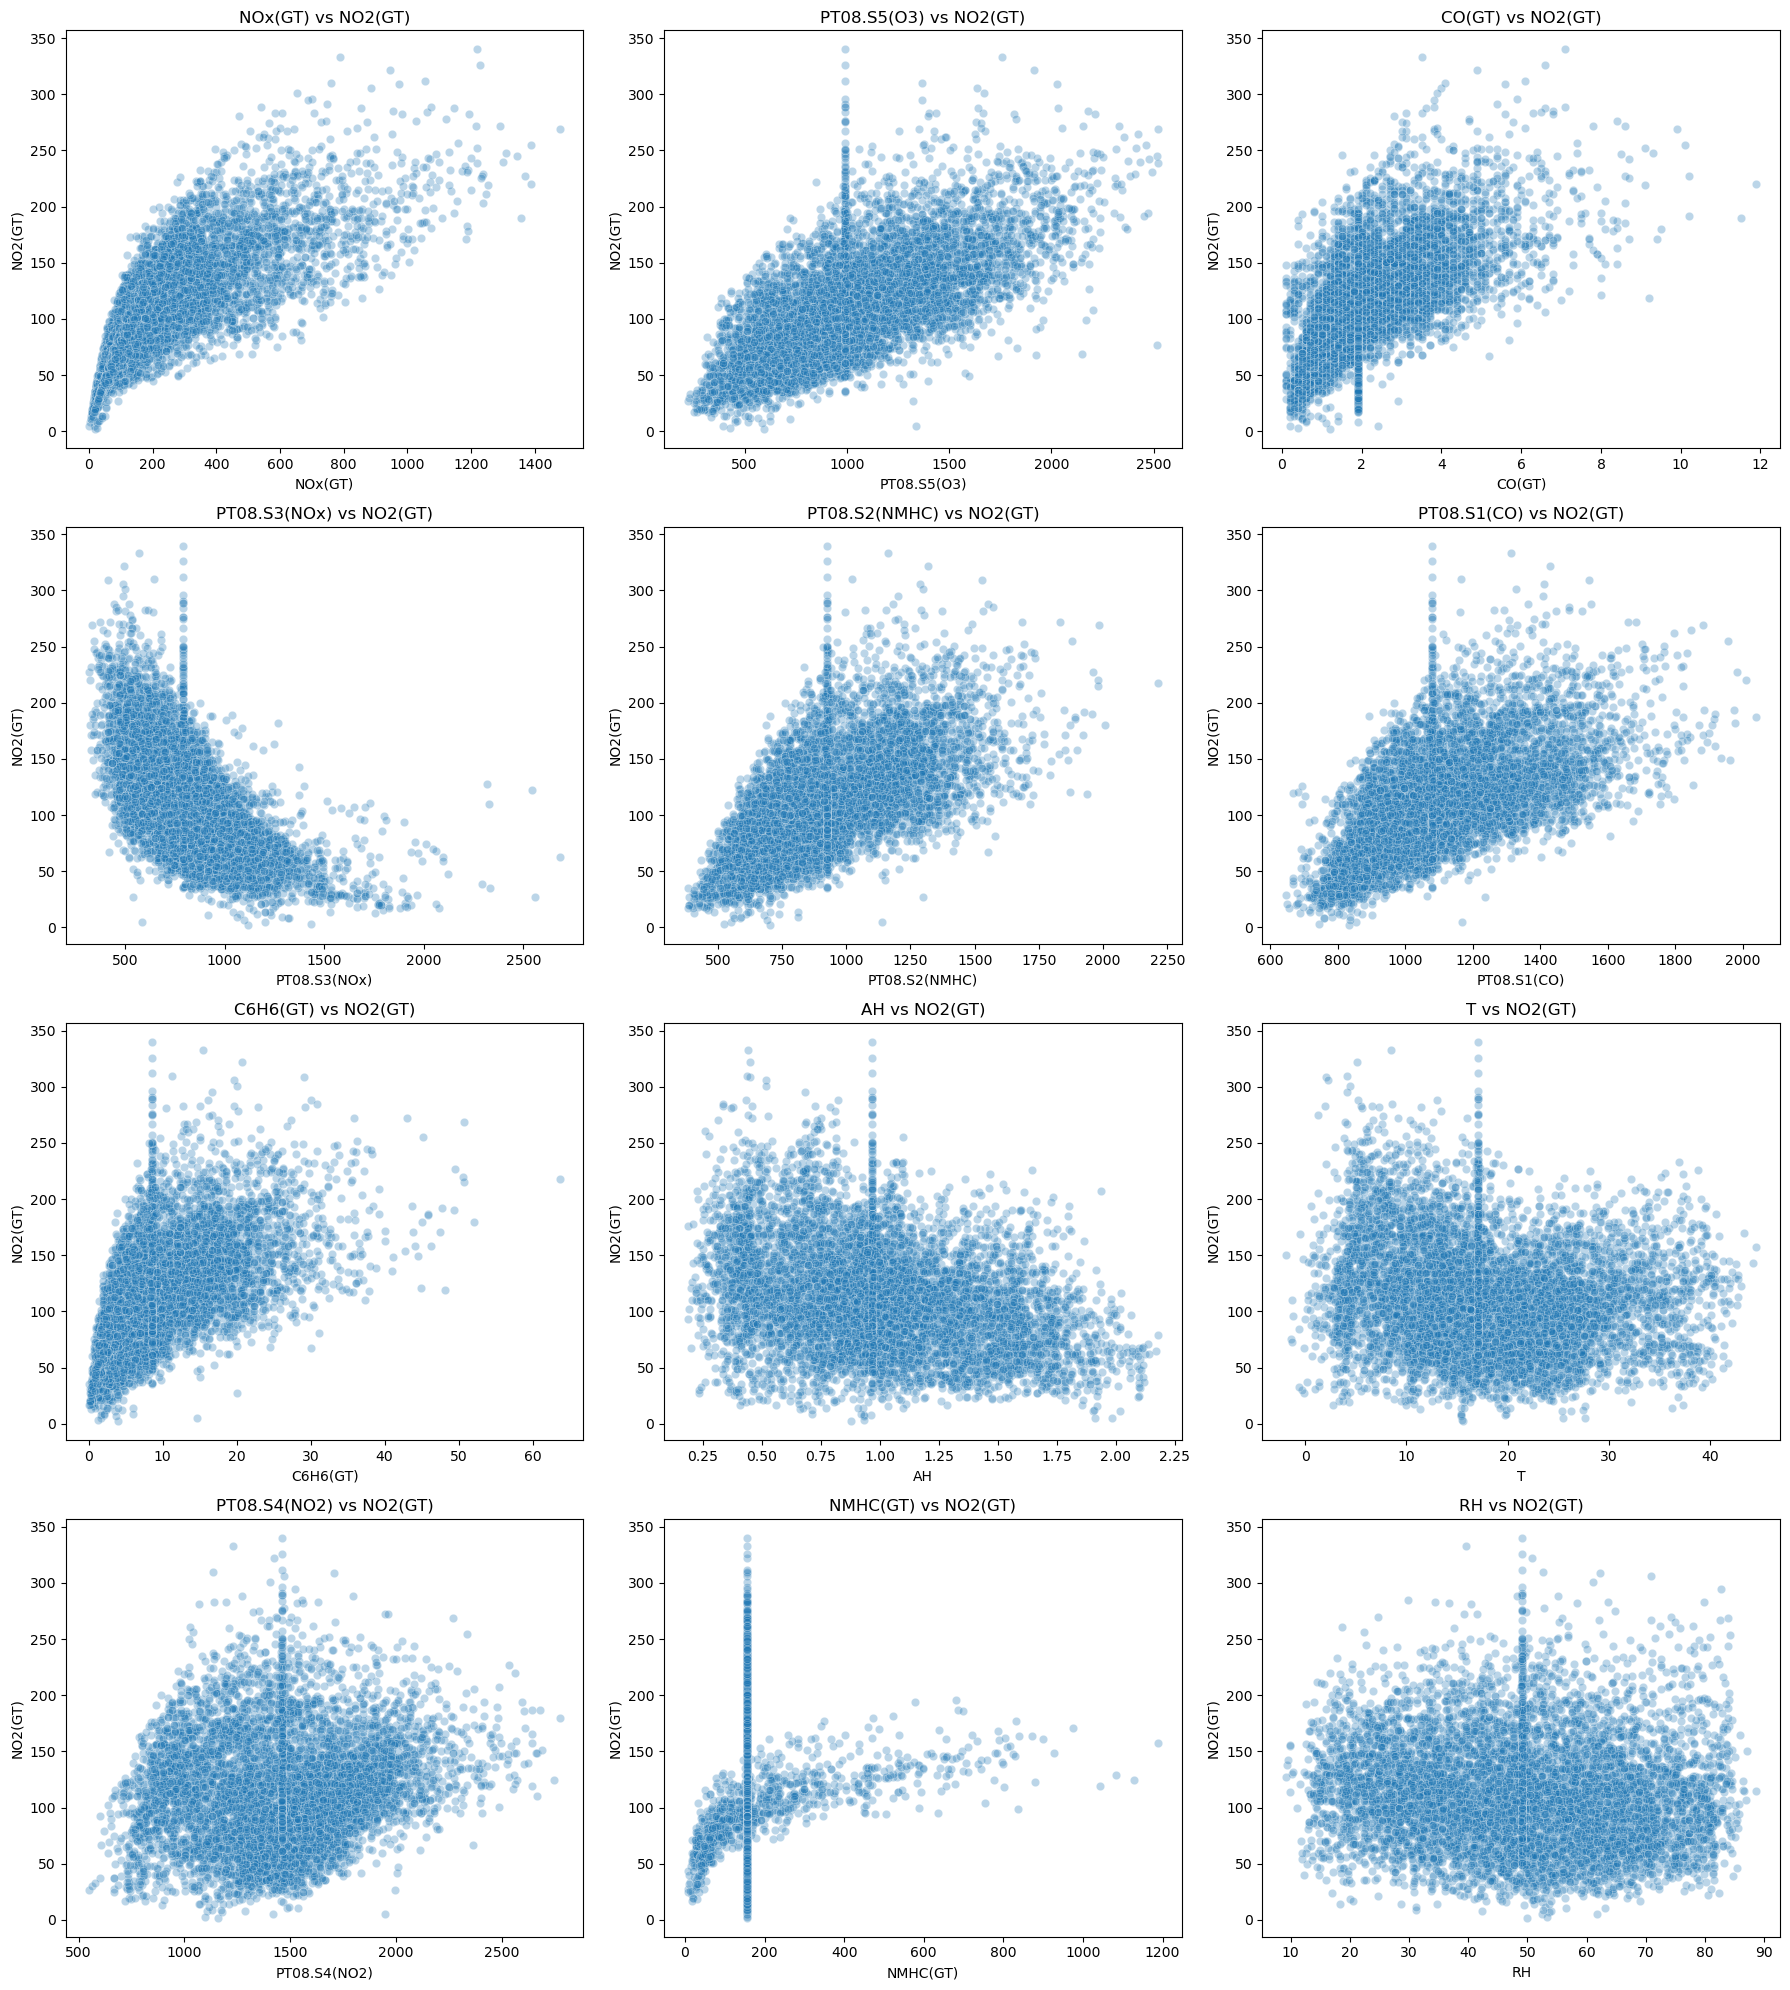

In [179]:
import math

print("Generando representaciones gráficas de las variables seleccionadas...")
num_features = len(features)
# Calculamos cuantas filas necesitamos (3 columnas por fila)
rows = math.ceil(num_features / 3)

fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
axes = axes.flatten() # Aplanamos para iterar fácil

for i, feature in enumerate(features):
    sns.scatterplot(data=df, x=feature, y='NO2(GT)', ax=axes[i], alpha=0.3)
    axes[i].set_title(f'{feature} vs NO2(GT)')

# Ocultamos los ejes vacíos si sobran huecos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

## 5. Preparación de los datos (División y Escalado)

Dividimos en un **80% de entrenamiento** y un **20% de prueba**.

In [180]:
print("Preparando variables X e y...")
X = df[features]
y = df['NO2(GT)']

print("Dividiendo el conjunto de datos (80% train / 20% test)...")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Escalando los datos...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Preparando variables X e y...
Dividiendo el conjunto de datos (80% train / 20% test)...
Escalando los datos...
Tamaño de entrenamiento: (6172, 12)
Tamaño de prueba: (1543, 12)


## 6. Creación y Compilación del Modelo

Definimos una arquitectura de red neuronal para regresión.

In [181]:
print("Creando el modelo de red neuronal...")
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1) # Salida de un único valor para regresión
])

print("Compilando el modelo con optimizador Adam...")
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error', metrics=['mae'])

model.summary()

Creando el modelo de red neuronal...
Compilando el modelo con optimizador Adam...


c:\Users\cnava\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento del Modelo

Entrenamos el modelo guardando el historial de pérdida.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configurar callbacks
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('mejor_modelo.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Entrenando con callbacks...")
history = model.fit(
    X_train, y_train, 
    epochs=300,            
    batch_size=32, 
    validation_split=0.2, 
    verbose=1,
    callbacks=callbacks_list  # <--- ¡Importante!
)

print("Entrenando el modelo...")
history = model.fit(
    X_train, y_train, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=1
)

Entrenando con callbacks...
Epoch 1/300
122/155 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 15214.5303 - mae: 113.0823
Epoch 1: val_loss improved from None to 15134.10352, saving model to mejor_modelo.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15103.1074 - mae: 112.8259 - val_loss: 15134.1035 - val_mae: 112.8664
Epoch 2/300
120/155 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 14940.7490 - mae: 111.8521
Epoch 2: val_loss improved from 15134.10352 to 14604.06836, saving model to mejor_modelo.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14744.3467 - mae: 111.2046 - val_loss: 14604.0684 - val_mae: 110.4695
Epoch 3/300
110/155 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 14330.6709 - mae: 109.0453
Epoch 3: val_loss improved from 14604.06836 to 13279.59961, saving model to mejor_modelo.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13891.3252 - mae: 107.2809 - val_loss: 13279.5996 - val_mae: 104.3991
Epoch 4/300
115/155 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 1274

## 8. Evaluación del Modelo

Analizamos la evolución de la pérdida durante el entrenamiento.

Evaluando el progreso del entrenamiento...


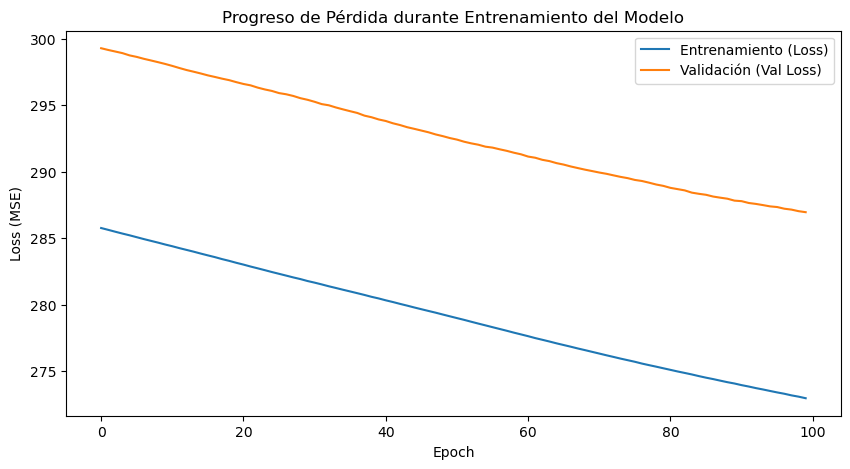

In [183]:
print("Evaluando el progreso del entrenamiento...")
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Entrenamiento (Loss)')
plt.plot(history.history['val_loss'], label='Validación (Val Loss)')
plt.title('Progreso de Pérdida durante Entrenamiento del Modelo')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## 9. Realizar predicciones y verificación final

Probamos el modelo con los datos de prueba y visualizamos algunos resultados.

In [184]:
print("Realizando predicciones sobre el conjunto de prueba...")
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Error Medio Absoluto (MAE) final: {test_mae:.2f}")

preds = model.predict(X_test[:10])
print("\nEjemplos de predicciones vs valores reales:")
for p, r in zip(preds, y_test[:10]):
    print(f"Predicho: {p[0]:.2f} | Real: {r:.2f}")

Realizando predicciones sobre el conjunto de prueba...
Error Medio Absoluto (MAE) final: 12.38
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Ejemplos de predicciones vs valores reales:
Predicho: 113.19 | Real: 92.00
Predicho: 65.73 | Real: 66.00
Predicho: 128.00 | Real: 94.00
Predicho: 140.79 | Real: 173.00
Predicho: 117.75 | Real: 113.00
Predicho: 152.93 | Real: 148.00
Predicho: 80.13 | Real: 91.00
Predicho: 107.21 | Real: 113.00
Predicho: 136.69 | Real: 128.00
Predicho: 129.53 | Real: 119.00
